In [46]:

import pandas as pd
import numpy as np

In [47]:
df= pd.read_csv("../data/weatherAUS.csv")
df.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [48]:
df_raw= df.copy(deep=True)
## create a seperate copy of the original data to avoid any changes to the original data
print("Records", df_raw.shape[0])
## gives the number of Records/rows in the dataset
print("Features",df_raw.shape[1])
#gives the number of Features/columns in the dataset

df_raw.info()
## gives the overall summary of the strucuture

Records 145460
Features 23
<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am     

In [49]:
missing_val = df_raw.isna().sum()
#checks every row and column for missing vlaues and then sums them up 

print("COLUMNS With Missing Values")
#heading of the results is printed
print(missing_val[missing_val>0].sort_values(ascending=False))
#checks using the operater condition if the missing values are greater than 0 and then sorts the results in descending order

COLUMNS With Missing Values
Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
Rainfall          3261
RainToday         3261
WindSpeed3pm      3062
Humidity9am       2654
WindSpeed9am      1767
Temp9am           1767
MinTemp           1485
MaxTemp           1261
dtype: int64


In [50]:
missing_percent = df_raw.isna().sum() / len(df_raw) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_val,
    "Missing Percentages": missing_percent.round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0].sort_values(
    "Missing Percentages",
    ascending=False
)

missing_summary

,Missing Values,Missing Percentages
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


### Initial Observations for today


In [51]:
duplicated_rows = df_raw.duplicated().sum()
print("Number of duplicated rows:", duplicated_rows)

Number of duplicated rows: 0


In [52]:
numeric_cols = df_raw.select_dtypes(include="number").columns
categorical_cols = df_raw.select_dtypes(include="str").columns

print("Numerical columns:")
print(numeric_cols.tolist())

print("\nCategorical columns:")
print(categorical_cols.tolist())

Numerical columns:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Categorical columns:
['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [53]:
df_raw[numeric_cols].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [54]:
missing_values = df_raw.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing values:")
print("\n" + missing_values.to_string())

print("Missing values percentage:")
missing_percentage = (missing_values / len(df_raw)) * 100
print("\n" + missing_percentage.to_string())    

Missing values:

Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
Rainfall          3261
RainToday         3261
WindSpeed3pm      3062
Humidity9am       2654
WindSpeed9am      1767
Temp9am           1767
MinTemp           1485
MaxTemp           1261
Missing values percentage:

Sunshine         48.009762
Evaporation      43.166506
Cloud3pm         40.807095
Cloud9am         38.421559
Pressure9am      10.356799
Pressure3pm      10.331363
WindDir9am        7.263853
WindGustDir       7.098859
WindGustSpeed     7.055548
Humidity3pm       3.098446
WindDir3pm        2.906641
Temp3pm           2.481094
RainTomorrow      2.245978
Rainfall          2.241853
RainToday         2.241853
WindSpeed3pm      2.105046
Humidity9am       1.824557
WindSpeed9am 

In [55]:
#Target Variable Analysis

#this will count the number of yes, no aswell as the missing values and save the result to target_counts

target_counts = df_raw["RainTomorrow"].value_counts(dropna=False)

print("RainTomorrow distribution:")
print(target_counts)

RainTomorrow distribution:
RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64


In [56]:
#does simliar things but instead og dislaing the number of rows it diplays the percetnage of the dataset
target_percent = df_raw["RainTomorrow"].value_counts(
    normalize=True,
    dropna=False
) * 100

print("\nRainTomorrow percentages:")
print(target_percent.round(2))

#inspecting the RainToday column
print("\nRainToday distribution:")
print(df_raw["RainToday"].value_counts(dropna=False))


RainTomorrow percentages:
RainTomorrow
No     75.84
Yes    21.91
NaN     2.25
Name: proportion, dtype: float64

RainToday distribution:
RainToday
No     110319
Yes     31880
NaN      3261
Name: count, dtype: int64


In [57]:
correlation_matrix = df_raw[numeric_cols].corr()

print(correlation_matrix.round(2))

print(
    df_raw.groupby("RainTomorrow")["Rainfall"].describe()
)

               MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
MinTemp           1.00     0.74      0.10         0.47      0.07   
MaxTemp           0.74     1.00     -0.07         0.59      0.47   
Rainfall          0.10    -0.07      1.00        -0.06     -0.23   
Evaporation       0.47     0.59     -0.06         1.00      0.37   
Sunshine          0.07     0.47     -0.23         0.37      1.00   
WindGustSpeed     0.18     0.07      0.13         0.20     -0.03   
WindSpeed9am      0.18     0.01      0.09         0.19      0.01   
WindSpeed3pm      0.18     0.05      0.06         0.13      0.05   
Humidity9am      -0.23    -0.50      0.22        -0.50     -0.49   
Humidity3pm       0.01    -0.51      0.26        -0.39     -0.63   
Pressure9am      -0.45    -0.33     -0.17        -0.27      0.04   
Pressure3pm      -0.46    -0.43     -0.13        -0.29     -0.02   
Cloud9am          0.08    -0.29      0.20        -0.18     -0.68   
Cloud3pm          0.02    -0.28      0.17       

In [58]:
sunshine_missing_percent = (
    df_raw["Sunshine"]
    .isna()
    .groupby(df_raw["Location"])
    .mean()
    * 100
)

sunshine_missing_percent = sunshine_missing_percent.sort_values(ascending=False)

print("Percentage of missing Sunshine values by Location:")
print(sunshine_missing_percent)

Percentage of missing Sunshine values by Location:
Location
Albury              100.000000
GoldCoast           100.000000
BadgerysCreek       100.000000
Bendigo             100.000000
Ballarat            100.000000
Katherine           100.000000
Wollongong          100.000000
Walpole             100.000000
Uluru               100.000000
Richmond            100.000000
SalmonGums          100.000000
Penrith             100.000000
NorahHead           100.000000
Nhil                100.000000
MountGinini         100.000000
Newcastle           100.000000
Launceston          100.000000
Tuggeranong         100.000000
Witchcliffe         100.000000
Cobar                81.721502
Canberra             55.733411
Williamtown          54.968428
CoffsHarbour         50.348953
Adelaide             44.597557
Sale                 39.581256
Woomera              33.300100
Moree                31.704885
AliceSprings         17.105263
Albany               17.105263
Cairns               15.657895
Portland  

In [59]:
#missing values in evaporation by location
evaporation_missing_percent = (df_raw["Evaporation"].isna().groupby(df_raw["Location"]).mean() * 100).sort_values(ascending=False)

print("Percentage of missing Evaporation values by Location:")
print(evaporation_missing_percent)

Percentage of missing Evaporation values by Location:
Location
Albury              100.000000
Ballarat            100.000000
BadgerysCreek       100.000000
GoldCoast           100.000000
PearceRAAF          100.000000
Witchcliffe         100.000000
Wollongong          100.000000
Walpole             100.000000
Uluru               100.000000
SalmonGums          100.000000
Tuggeranong         100.000000
Penrith             100.000000
MountGinini         100.000000
Nhil                100.000000
NorahHead           100.000000
Newcastle           100.000000
Launceston           95.361842
Bendigo              61.019737
Canberra             46.682189
Adelaide             46.633260
Richmond             46.028581
CoffsHarbour         40.677966
Sale                 39.049518
Williamtown          35.327351
Moree                23.828514
Woomera              14.589565
Dartmoor             13.592556
Portland             13.592556
MountGambier         13.486842
Cairns               12.171053
Cobar  

In [60]:
missing_percent_by_location = df_raw.groupby("Location").apply(
    lambda x: x.isnull().mean() * 100
)

print("Percentage of missing values by Location:")
print(missing_percent_by_location)

high_missing_locations = missing_percent_by_location[
    (missing_percent_by_location > 70).any(axis=1)
].index.tolist()

print(high_missing_locations)
print(f"Number of locations with high missing values: {len(high_missing_locations)}")
number_of_rows_with_high_missing_values = df_raw[df_raw["Location"].isin(high_missing_locations)].shape[0]
print(f"Number of rows with high missing values: {number_of_rows_with_high_missing_values}")

Percentage of missing values by Location:
                  Date    MinTemp    MaxTemp   Rainfall  Evaporation  \
Location                                                               
Adelaide           0.0   0.062637   0.093956   3.194488    46.633260   
Albany             0.0   2.072368   1.776316   0.789474     9.539474   
Albury             0.0   0.361842   0.361842   0.953947   100.000000   
AliceSprings       0.0   0.032895   0.065789   0.263158     7.072368   
BadgerysCreek      0.0   1.196411   0.963775   2.691924   100.000000   
Ballarat           0.0   0.032895   0.032895   0.394737   100.000000   
Bendigo            0.0   0.065789   0.164474   0.197368    61.019737   
Brisbane           0.0   0.281867   0.438459   1.002192     0.595052   
Cairns             0.0   0.032895   0.000000   1.710526    12.171053   
Canberra           0.0   0.174622   0.087311   0.523865    46.682189   
Cobar              0.0   0.199402   0.099701   0.697906    11.399136   
CoffsHarbour       0.0

In [61]:
#inspection table to show why each location was deleted
high_missing_details = missing_percent_by_location.loc[
    high_missing_locations
]

high_missing_details = high_missing_details.loc[
    :,
    (high_missing_details > 70).any()
]

print(high_missing_details.round(2))

               Evaporation  Sunshine  WindGustDir  WindGustSpeed  Pressure9am  \
Location                                                                        
Adelaide             46.63     44.60         0.81           0.81         0.25   
Albany                9.54     17.11       100.00         100.00         0.82   
Albury              100.00    100.00         1.05           1.05         0.16   
BadgerysCreek       100.00    100.00         2.53           2.53         5.58   
Ballarat            100.00    100.00         1.02           1.02         0.79   
Bendigo              61.02    100.00         1.35           1.32         0.49   
Cobar                11.40     81.72         1.40           1.40         1.00   
Dartmoor             13.59     14.72         2.29           2.29         2.13   
GoldCoast           100.00    100.00         3.95           3.95         0.03   
Katherine             5.89    100.00         1.84           1.84         0.06   
Launceston           95.36  

In [62]:
original_rows = len(df_raw)

df_clean = df_raw[
    ~df_raw["Location"].isin(high_missing_locations)
].copy()

rows_removed = original_rows - len(df_clean)

print("Original rows:", original_rows)
print("Rows removed:", rows_removed)
print("Remaining rows:", len(df_clean))
print("Percentage removed:", round(rows_removed / original_rows * 100, 2))

Original rows: 145460
Rows removed: 68429
Remaining rows: 77031
Percentage removed: 47.04


In [63]:
missing_after_cleaning = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": (df_clean.isnull().mean() * 100).round(2)
})

missing_after_cleaning = missing_after_cleaning[
    missing_after_cleaning["Missing Values"] > 0
].sort_values("Missing Percentage", ascending=False)

print(missing_after_cleaning)

               Missing Values  Missing Percentage
Sunshine                11815               15.34
Cloud3pm                 9645               12.52
Evaporation              8516               11.06
Cloud9am                 8269               10.73
WindDir9am               2788                3.62
WindGustDir              2716                3.53
WindGustSpeed            2690                3.49
RainTomorrow             1708                2.22
Rainfall                 1703                2.21
RainToday                1703                2.21
Pressure9am              1126                1.46
Pressure3pm              1122                1.46
WindDir3pm                895                1.16
Humidity9am               757                0.98
Humidity3pm               687                0.89
WindSpeed9am              675                0.88
WindSpeed3pm              665                0.86
Temp9am                   609                0.79
MinTemp                   559                0.73


#Trying to remove values that are only fully missing

In [64]:
#realoding the orginal dataset staritng fresh
df_clean = df_raw.copy(deep=True)

print("original Set:", df_clean.shape)

original Set: (145460, 23)


In [65]:
#filling each columns with its own mean or median value depending on the distribution of the data
numeric_columns = df_clean.select_dtypes(
    include="number"
).columns

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

In [66]:
#checking if any numvericla values are still missing
print(
    df_clean[numeric_columns]
    .isna()
    .sum()
)

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
dtype: int64


In [67]:
#filling in categorical columns mmssing value with the mode
categorical_fill_columns = [
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "RainToday"
]

for col in categorical_fill_columns:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].mode()[0]
    )

In [68]:
#priting them to check there are no missing values left
print(
    df_clean[categorical_fill_columns]
    .isna()
    .sum()
)

WindGustDir    0
WindDir9am     0
WindDir3pm     0
RainToday      0
dtype: int64


In [69]:
print("Missing RainTomorrow before:")
print(df_clean["RainTomorrow"].isna().sum())

Missing RainTomorrow before:
3267


In [70]:
df_clean = df_clean.dropna(
    subset=["RainTomorrow"]
).copy()

In [71]:
print("Missing RainTomorrow after:")
print(df_clean["RainTomorrow"].isna().sum())

print("Rows remaining:")
print(df_clean.shape[0])

Missing RainTomorrow after:
0
Rows remaining:
142193


In [72]:
df_clean = df_clean.reset_index(drop=True)

In [73]:
print("Total missing values:")
print(df_clean.isna().sum().sum())

Total missing values:
0


In [74]:
categorical_col = [
    "Location",
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "RainToday",
    "RainTomorrow"
]

In [75]:
for col in categorical_cols:
    print("\n", col)
    print(df_clean[col].unique())


 Date
<StringArray>
['2008-12-01', '2008-12-02', '2008-12-03', '2008-12-04', '2008-12-05',
 '2008-12-06', '2008-12-07', '2008-12-08', '2008-12-09', '2008-12-10',
 ...
 '2008-01-22', '2008-01-23', '2008-01-24', '2008-01-25', '2008-01-26',
 '2008-01-27', '2008-01-28', '2008-01-29', '2008-01-30', '2008-01-31']
Length: 3436, dtype: str

 Location
<StringArray>
[          'Albury',    'BadgerysCreek',            'Cobar',
     'CoffsHarbour',            'Moree',        'Newcastle',
        'NorahHead',    'NorfolkIsland',          'Penrith',
         'Richmond',           'Sydney',    'SydneyAirport',
       'WaggaWagga',      'Williamtown',       'Wollongong',
         'Canberra',      'Tuggeranong',      'MountGinini',
         'Ballarat',          'Bendigo',             'Sale',
 'MelbourneAirport',        'Melbourne',          'Mildura',
             'Nhil',         'Portland',         'Watsonia',
         'Dartmoor',         'Brisbane',           'Cairns',
        'GoldCoast',       'To

In [76]:
#removng accidnetal spaces in the categorical columns
for col in categorical_cols:
    df_clean[col] = df_clean[col].str.strip()

In [77]:
for col in categorical_cols:
    print("\n", col)
    print(df_clean[col].unique())


 Date
<StringArray>
['2008-12-01', '2008-12-02', '2008-12-03', '2008-12-04', '2008-12-05',
 '2008-12-06', '2008-12-07', '2008-12-08', '2008-12-09', '2008-12-10',
 ...
 '2008-01-22', '2008-01-23', '2008-01-24', '2008-01-25', '2008-01-26',
 '2008-01-27', '2008-01-28', '2008-01-29', '2008-01-30', '2008-01-31']
Length: 3436, dtype: str

 Location
<StringArray>
[          'Albury',    'BadgerysCreek',            'Cobar',
     'CoffsHarbour',            'Moree',        'Newcastle',
        'NorahHead',    'NorfolkIsland',          'Penrith',
         'Richmond',           'Sydney',    'SydneyAirport',
       'WaggaWagga',      'Williamtown',       'Wollongong',
         'Canberra',      'Tuggeranong',      'MountGinini',
         'Ballarat',          'Bendigo',             'Sale',
 'MelbourneAirport',        'Melbourne',          'Mildura',
             'Nhil',         'Portland',         'Watsonia',
         'Dartmoor',         'Brisbane',           'Cairns',
        'GoldCoast',       'To

In [78]:
#checking invalid values
numeric_cols = df_clean.select_dtypes(
    include="number"
).columns

print(
    df_clean[numeric_cols]
    .agg(["min", "max"])
    .T
)

                 min     max
MinTemp         -8.5    33.9
MaxTemp         -4.8    48.1
Rainfall         0.0   371.0
Evaporation      0.0   145.0
Sunshine         0.0    14.5
WindGustSpeed    6.0   135.0
WindSpeed9am     0.0   130.0
WindSpeed3pm     0.0    87.0
Humidity9am      0.0   100.0
Humidity3pm      0.0   100.0
Pressure9am    980.5  1041.0
Pressure3pm    977.1  1039.6
Cloud9am         0.0     9.0
Cloud3pm         0.0     9.0
Temp9am         -7.2    40.2
Temp3pm         -5.4    46.7


In [79]:
invalid_humidity = df_clean[
    (df_clean["Humidity9am"] < 0)
    | (df_clean["Humidity9am"] > 100)
    | (df_clean["Humidity3pm"] < 0)
    | (df_clean["Humidity3pm"] > 100)
]

print("Invalid humidity rows:")
print(invalid_humidity.shape[0])

Invalid humidity rows:
0


In [80]:
invalid_rainfall = df_clean[
    df_clean["Rainfall"] < 0
]

print("Negative rainfall rows:")
print(invalid_rainfall.shape[0])

Negative rainfall rows:
0


In [81]:
for col in ["Cloud9am", "Cloud3pm"]:
    invalid_cloud = df_clean[
        (df_clean[col] < 0)
        | (df_clean[col] > 8)
    ]

    print(
        col,
        "invalid values:",
        invalid_cloud.shape[0]
    )
    print(invalid_cloud[col])

df_clean.loc[
    df_clean["Cloud9am"] > 8,
    "Cloud9am"
] = 8

df_clean.loc[
    df_clean["Cloud3pm"] > 8,
    "Cloud3pm"
] = 8   


Cloud9am invalid values: 2
30097    9.0
45981    9.0
Name: Cloud9am, dtype: float64
Cloud3pm invalid values: 1
104342    9.0
Name: Cloud3pm, dtype: float64


In [82]:
missing_after_cleaning = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": (df_clean.isnull().mean() * 100).round(2)
})

print("Missing values after cleaning:")
print(missing_after_cleaning)


Missing values after cleaning:
               Missing Values  Missing Percentage
Date                        0                 0.0
Location                    0                 0.0
MinTemp                     0                 0.0
MaxTemp                     0                 0.0
Rainfall                    0                 0.0
Evaporation                 0                 0.0
Sunshine                    0                 0.0
WindGustDir                 0                 0.0
WindGustSpeed               0                 0.0
WindDir9am                  0                 0.0
WindDir3pm                  0                 0.0
WindSpeed9am                0                 0.0
WindSpeed3pm                0                 0.0
Humidity9am                 0                 0.0
Humidity3pm                 0                 0.0
Pressure9am                 0                 0.0
Pressure3pm                 0                 0.0
Cloud9am                    0                 0.0
Cloud3pm           

In [83]:
print("Number of rows in cleaned dataset:", len(df_clean))

Number of rows in cleaned dataset: 142193


In [84]:
print(df_clean["Evaporation"].groupby(df_clean["Location"]).mean().sort_values(ascending=False))

Location
Woomera             9.359164
AliceSprings        8.735467
Katherine           7.193457
Townsville          7.126772
Moree               7.017169
Cobar               6.509304
Williamtown         6.309087
Darwin              6.293390
Cairns              6.050837
Mildura             5.891753
PerthAirport        5.662546
Perth               5.606326
Brisbane            5.405188
Adelaide            5.346958
SydneyAirport       5.245524
Sydney              5.181510
WaggaWagga          5.144220
Nuriootpa           5.072585
Richmond            5.048424
Launceston          4.863639
Walpole             4.800000
Witchcliffe         4.800000
PearceRAAF          4.800000
GoldCoast           4.800000
BadgerysCreek       4.800000
Albury              4.800000
Ballarat            4.800000
Tuggeranong         4.800000
Uluru               4.800000
Nhil                4.800000
Penrith             4.800000
Newcastle           4.800000
MountGinini         4.800000
Wollongong          4.800000
Salmo

In [85]:
print(df_clean["Sunshine"].groupby(df_clean["Location"]).mean().sort_values(ascending=False))

Location
AliceSprings        9.382679
PearceRAAF          8.893266
Woomera             8.844147
PerthAirport        8.794649
Perth               8.783934
Moree               8.757218
Darwin              8.499217
Mildura             8.465115
Townsville          8.452291
Cobar               8.450502
Newcastle           8.400000
Katherine           8.400000
Albury              8.400000
Bendigo             8.400000
GoldCoast           8.400000
BadgerysCreek       8.400000
Ballarat            8.400000
Wollongong          8.400000
Witchcliffe         8.400000
Uluru               8.400000
SalmonGums          8.400000
Richmond            8.400000
Tuggeranong         8.400000
MountGinini         8.400000
Launceston          8.400000
NorahHead           8.400000
Penrith             8.400000
Nhil                8.400000
Walpole             8.400000
WaggaWagga          8.225101
Brisbane            8.087599
Adelaide            8.043916
Canberra            7.959070
CoffsHarbour        7.876092
Willi

In [86]:
#rechecking everything after cleaning the data

print(df_clean.head(15))
print(df_clean.info())


          Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0   2008-12-01   Albury     13.4     22.9       0.6          4.8       8.4   
1   2008-12-02   Albury      7.4     25.1       0.0          4.8       8.4   
2   2008-12-03   Albury     12.9     25.7       0.0          4.8       8.4   
3   2008-12-04   Albury      9.2     28.0       0.0          4.8       8.4   
4   2008-12-05   Albury     17.5     32.3       1.0          4.8       8.4   
5   2008-12-06   Albury     14.6     29.7       0.2          4.8       8.4   
6   2008-12-07   Albury     14.3     25.0       0.0          4.8       8.4   
7   2008-12-08   Albury      7.7     26.7       0.0          4.8       8.4   
8   2008-12-09   Albury      9.7     31.9       0.0          4.8       8.4   
9   2008-12-10   Albury     13.1     30.1       1.4          4.8       8.4   
10  2008-12-11   Albury     13.4     30.4       0.0          4.8       8.4   
11  2008-12-12   Albury     15.9     21.7       2.2          4.8

In [87]:
import numpy as np
import pandas as pd

df_eda = df_clean.copy(deep=True)

#Converting date into numerical columns
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Day"] = df_clean["Date"].dt.day

df_clean = df_clean.drop(columns=["Date"])


#Converting RainToday and RainTomorrow into binary values
df_clean["RainToday"] = df_clean["RainToday"].map({
    "No": 0,
    "Yes": 1
})
df_clean["RainTomorrow"] = df_clean["RainTomorrow"].map({
    "No": 0,
    "Yes": 1
})


#Using sine and cosine transformations to convert wind direction into numerical values, this decreases the number of columns 
#and helps the model understand the directions ebtter 
wind_angles = {
    "N": 0,
    "NNE": 22.5,
    "NE": 45,
    "ENE": 67.5,
    "E": 90,
    "ESE": 112.5,
    "SE": 135,
    "SSE": 157.5,
    "S": 180,
    "SSW": 202.5,
    "SW": 225,
    "WSW": 247.5,
    "W": 270,
    "WNW": 292.5,
    "NW": 315,
    "NNW": 337.5
}
wind_cols = [
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm"
]
for col in wind_cols:
    angle = df_clean[col].map(wind_angles)

    df_clean[col + "_sin"] = np.sin(
        np.radians(angle)
    )

    df_clean[col + "_cos"] = np.cos(
        np.radians(angle)
    )

df_clean = df_clean.drop(columns=wind_cols)

# One-hot encoding Location
df_clean = pd.get_dummies(
    df_clean,
    columns=["Location"],
    dtype=int
)

# Checking whether any categorical columns remain
categorical_cols = df_clean.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Remaining categorical columns:")
print(categorical_cols)

print("\nFinal dataset shape:")
print(df_clean.shape)

print("\nFinal dataset preview:")
print(df_clean.head())

Remaining categorical columns:
[]

Final dataset shape:
(142193, 76)

Final dataset preview:
   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0     13.4     22.9       0.6          4.8       8.4           44.0   
1      7.4     25.1       0.0          4.8       8.4           44.0   
2     12.9     25.7       0.0          4.8       8.4           46.0   
3      9.2     28.0       0.0          4.8       8.4           24.0   
4     17.5     32.3       1.0          4.8       8.4           41.0   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  \
0          20.0          24.0         71.0         22.0  ...   
1           4.0          22.0         44.0         25.0  ...   
2          19.0          26.0         38.0         30.0  ...   
3          11.0           9.0         45.0         16.0  ...   
4           7.0          20.0         82.0         33.0  ...   

   Location_Townsville  Location_Tuggeranong  Location_Uluru  \
0                    0         

In [88]:
#checking cleaned numeric features
numeric_eda = df_eda.select_dtypes(
    include="number"
).columns

numerical_summary = (
    df_eda[numeric_eda]
    .describe()
    .round(2)
)

print("Numerical Summary:")
print(numerical_summary)

Numerical Summary:
         MinTemp    MaxTemp   Rainfall  Evaporation   Sunshine  WindGustSpeed  \
count  142193.00  142193.00  142193.00    142193.00  142193.00      142193.00   
mean       12.19      23.23       2.33         5.18       7.99          39.92   
std         6.39       7.11       8.43         3.19       2.76          13.14   
min        -8.50      -4.80       0.00         0.00       0.00           6.00   
25%         7.60      17.90       0.00         4.00       8.20          31.00   
50%        12.00      22.60       0.00         4.80       8.40          39.00   
75%        16.80      28.20       0.60         5.40       8.70          46.00   
max        33.90      48.10     371.00       145.00      14.50         135.00   

       WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  \
count     142193.00     142193.00    142193.00    142193.00    142193.00   
mean          13.99         18.64        68.86        51.50      1017.65   
std            8.85    

In [89]:
#checking cleaned categoric feautres
categorical_eda = df_eda.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_eda:
    print("\n", col)

    print(
        df_eda[col]
        .value_counts()
    )


 Date
Date
2013-03-02    49
2013-03-03    49
2013-03-04    49
2013-03-06    49
2013-03-07    49
              ..
2008-01-27     1
2008-01-28     1
2008-01-29     1
2008-01-30     1
2008-01-31     1
Name: count, Length: 3436, dtype: int64

 Location
Location
Canberra            3418
Sydney              3337
Perth               3193
Darwin              3192
Hobart              3188
Brisbane            3161
Adelaide            3090
Bendigo             3034
Townsville          3033
AliceSprings        3031
MountGambier        3030
Ballarat            3028
Launceston          3028
Albany              3016
Albury              3011
MelbourneAirport    3009
PerthAirport        3009
Mildura             3007
SydneyAirport       3005
Nuriootpa           3002
Sale                3000
Watsonia            2999
Tuggeranong         2998
Portland            2996
Woomera             2990
Cobar               2988
Cairns              2988
Wollongong          2983
GoldCoast           2980
WaggaWagga      

C:\Users\kunap\AppData\Local\Temp\ipykernel_25268\3786914152.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_eda = df_eda.select_dtypes(


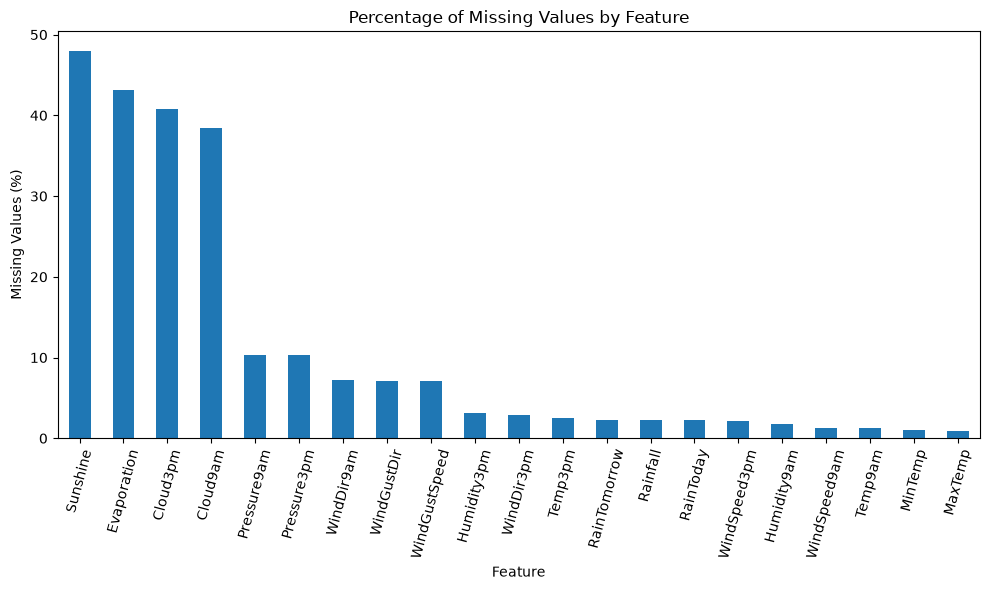

In [ ]:
#figurin out the missingness pattern
import matplotlib.pyplot as plt


missing_percent = (
    df_raw.isna().mean() * 100
).sort_values(ascending=False)

missing_percent = missing_percent[
    missing_percent > 0
]

plt.figure(figsize=(10, 6))

missing_percent.plot(kind="bar")

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [ ]:
#so that matplotlib wokrds
%pip install matplotlib

  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
#calculate the counts and percetnages of the target variable RainTomorrow
target_counts = df_eda["RainTomorrow"].value_counts()

target_percent = (
    df_eda["RainTomorrow"]
    .value_counts(normalize=True)
    * 100
)

print("RainTomorrow counts:")
print(target_counts)

print("\nRainTomorrow percentages:")
print(target_percent.round(2))


RainTomorrow counts:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

RainTomorrow percentages:
RainTomorrow
No     77.58
Yes    22.42
Name: proportion, dtype: float64


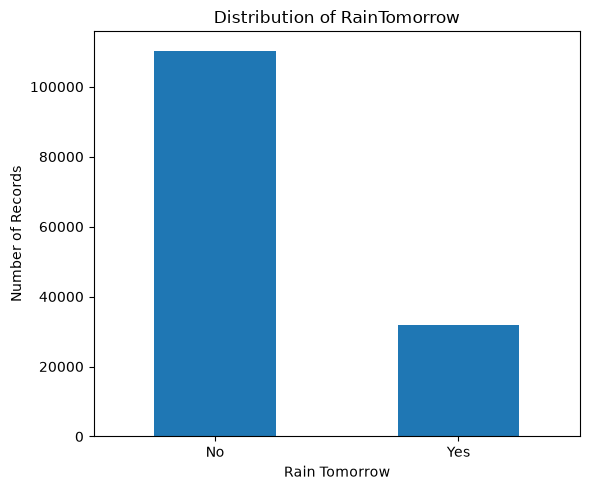

In [97]:
# plotting the graph for the distribution of the target variable RainTomorrow
plt.figure(figsize=(6, 5))

target_counts.plot(kind="bar")

plt.title("Distribution of RainTomorrow")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

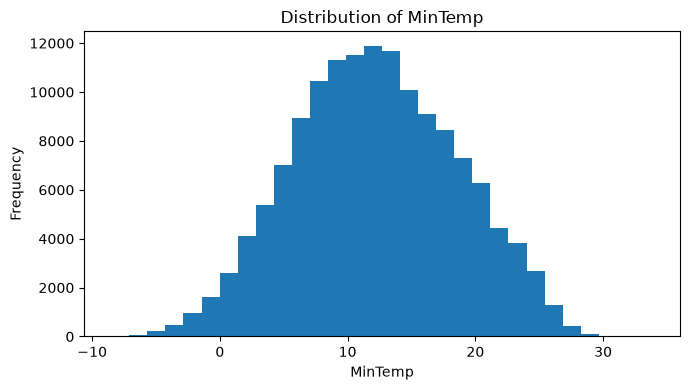

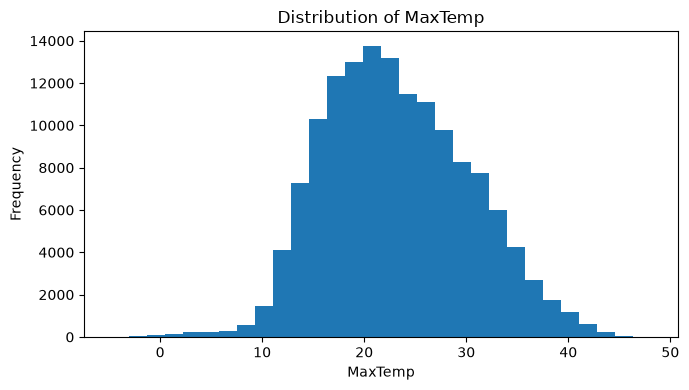

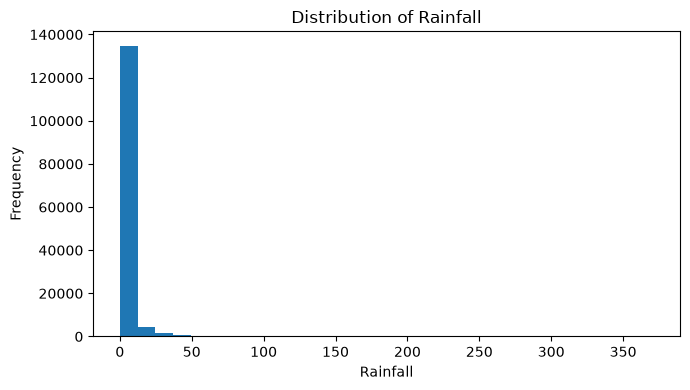

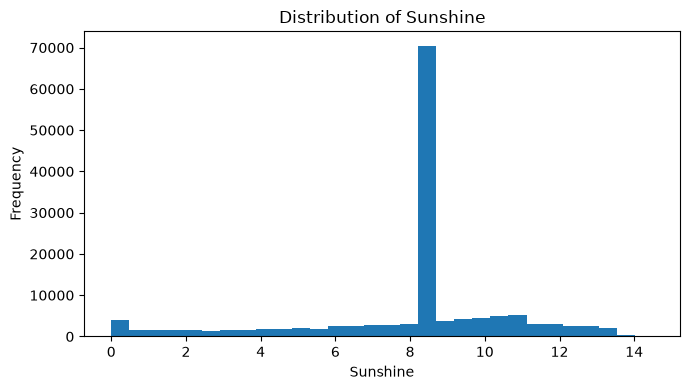

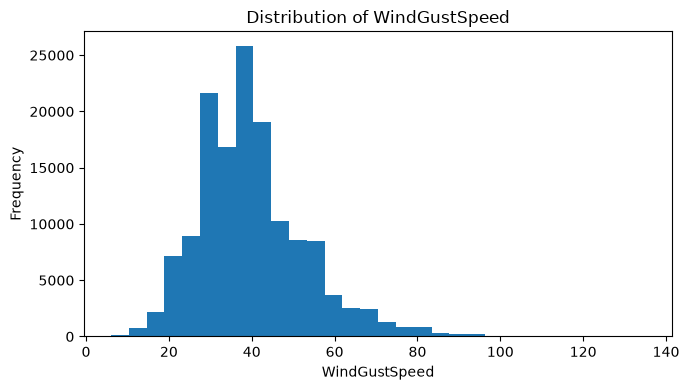

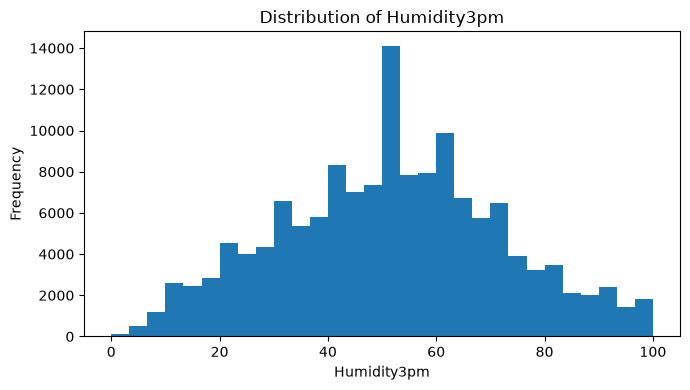

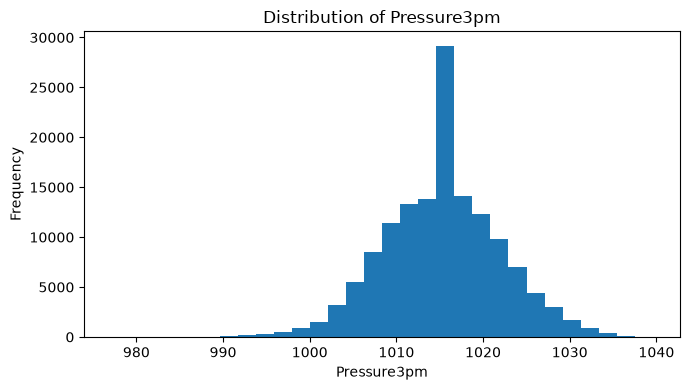

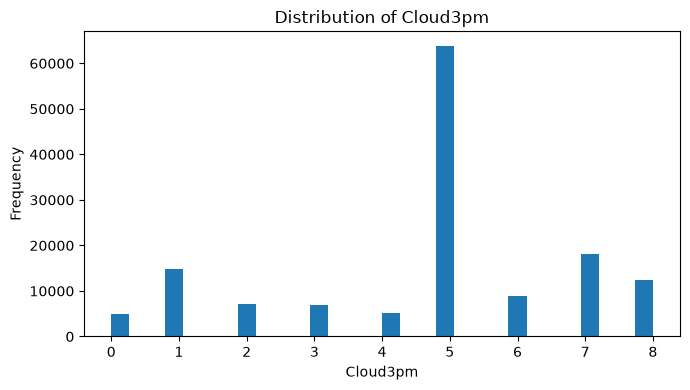

In [98]:
#plotting a histrogra to see what normally ocurs in the feautre and how the 
# values are spread out in the feautre, view the whole distrubution
distribution_cols = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Sunshine",
    "WindGustSpeed",
    "Humidity3pm",
    "Pressure3pm",
    "Cloud3pm"
]

for col in distribution_cols:
    plt.figure(figsize=(7, 4))

    plt.hist(
        df_eda[col],
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


C:\Users\kunap\AppData\Local\Temp\ipykernel_25268\1351419737.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


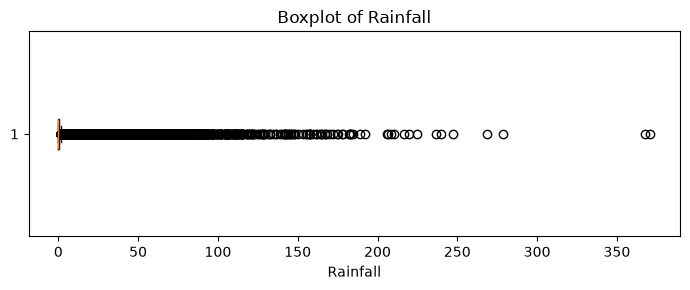

C:\Users\kunap\AppData\Local\Temp\ipykernel_25268\1351419737.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


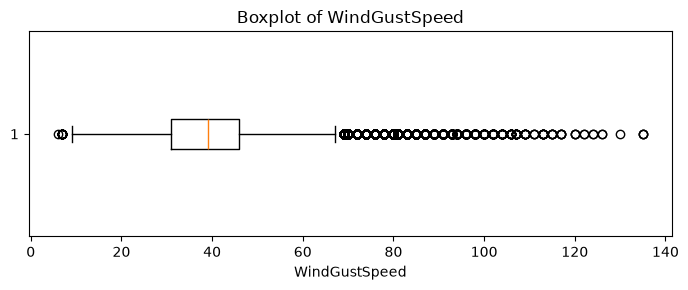

C:\Users\kunap\AppData\Local\Temp\ipykernel_25268\1351419737.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


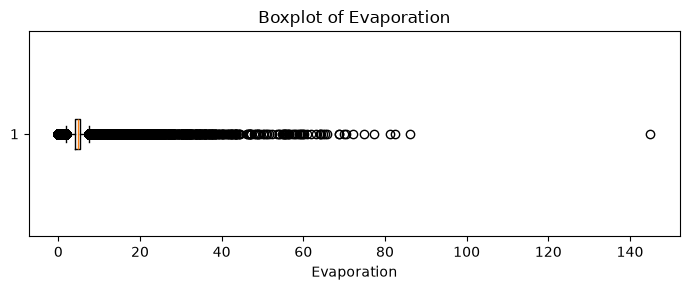

C:\Users\kunap\AppData\Local\Temp\ipykernel_25268\1351419737.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


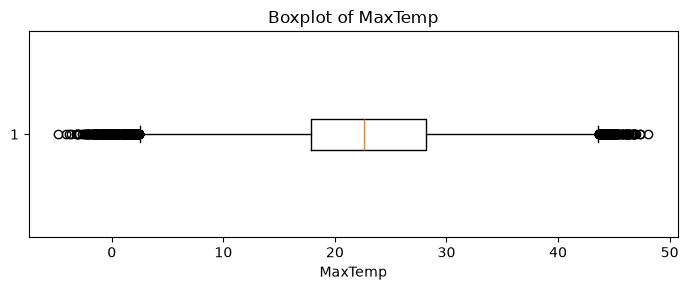

C:\Users\kunap\AppData\Local\Temp\ipykernel_25268\1351419737.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


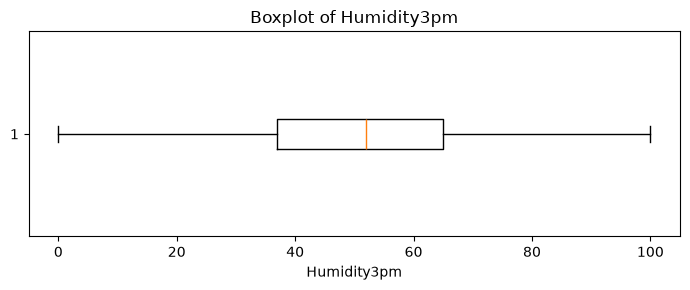

In [99]:
#producing boc plots for the unsual values in the features, this will help us see the outliers in the data
boxplot_cols = [
    "Rainfall",
    "WindGustSpeed",
    "Evaporation",
    "MaxTemp",
    "Humidity3pm"
]

for col in boxplot_cols:
    plt.figure(figsize=(7, 3))

    plt.boxplot(
        df_eda[col].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [ ]:
#analysing relationships between numerical features and the target variable RainTomorrow
comparison_cols = [
    "Rainfall",
    "Sunshine",
    "WindGustSpeed",
    "Humidity3pm",
    "Pressure3pm",
    "Cloud3pm",
    "MaxTemp"
]

rain_comparison = df_eda.groupby(
    "RainTomorrow"
)[comparison_cols].mean()

print(rain_comparison.round(2))

              Rainfall  Sunshine  WindGustSpeed  Humidity3pm  Pressure3pm  \
RainTomorrow                                                                
No                1.26      8.48          38.33        46.64      1016.02   
Yes               6.01      6.33          45.41        68.29      1012.58   

              Cloud3pm  MaxTemp  
RainTomorrow                     
No                4.37    23.83  
Yes               5.87    21.12  


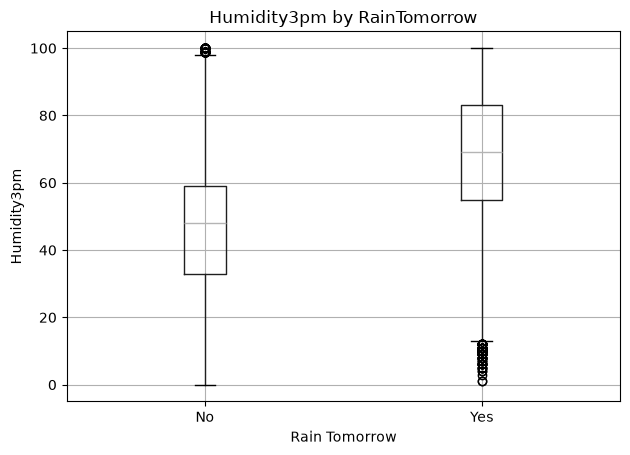

In [101]:
# Comparing the distribution of Humidity3pm
# between RainTomorrow = Yes and RainTomorrow = No
df_eda.boxplot(
    column="Humidity3pm",
    by="RainTomorrow"
)

plt.title("Humidity3pm by RainTomorrow")
plt.suptitle("")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Humidity3pm")

plt.tight_layout()
plt.show()

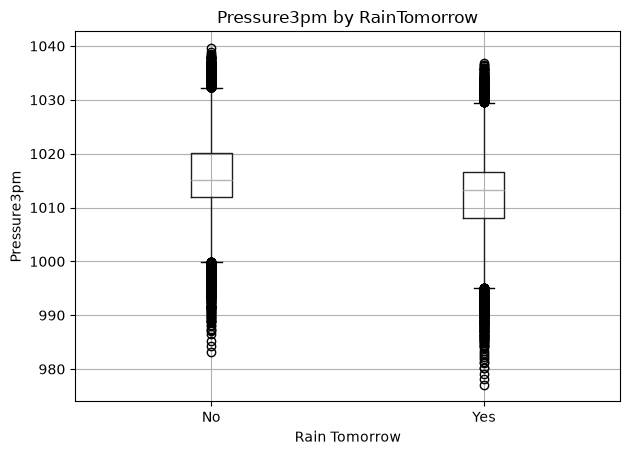

In [102]:
# Comparing the distribution of Pressure3pm
# between the two RainTomorrow classes
df_eda.boxplot(
    column="Pressure3pm",
    by="RainTomorrow"
)

plt.title("Pressure3pm by RainTomorrow")
plt.suptitle("")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Pressure3pm")

plt.tight_layout()
plt.show()

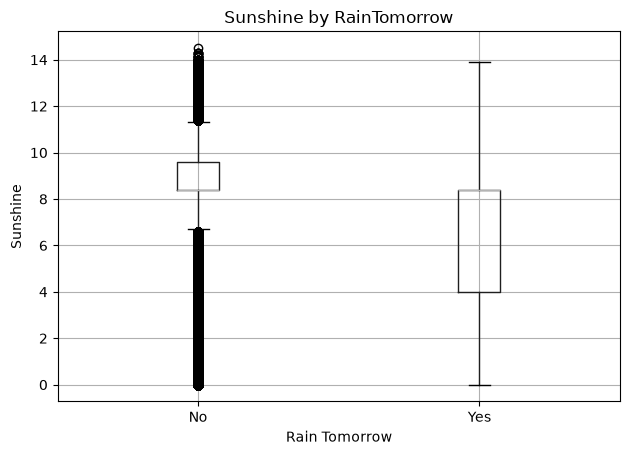

In [103]:
# Comparing the distribution of Sunshine
# between the two RainTomorrow classes
df_eda.boxplot(
    column="Sunshine",
    by="RainTomorrow"
)

plt.title("Sunshine by RainTomorrow")
plt.suptitle("")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Sunshine")

plt.tight_layout()
plt.show()

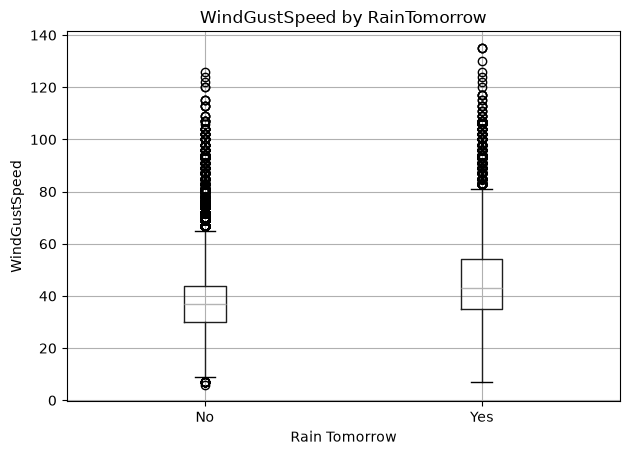

In [104]:
# Comparing the distribution of WindGustSpeed
# between the two RainTomorrow classes
df_eda.boxplot(
    column="WindGustSpeed",
    by="RainTomorrow"
)

plt.title("WindGustSpeed by RainTomorrow")
plt.suptitle("")
plt.xlabel("Rain Tomorrow")
plt.ylabel("WindGustSpeed")

plt.tight_layout()
plt.show()

In [105]:
# Comparing RainToday with the RainTomorrow target
rain_today_tomorrow = pd.crosstab(
    df_eda["RainToday"],
    df_eda["RainTomorrow"],
    normalize="index"
) * 100

# Printing the percentage of RainTomorrow outcomes
# for each RainToday category
print(rain_today_tomorrow.round(2))

RainTomorrow     No    Yes
RainToday                 
No            84.40  15.60
Yes           53.59  46.41


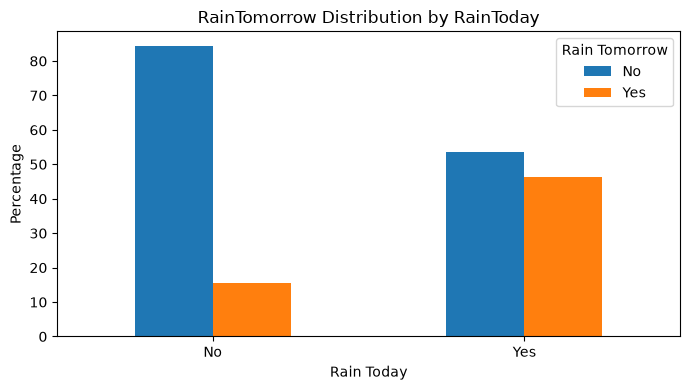

In [106]:
# Plotting the relationship between RainToday and RainTomorrow
rain_today_tomorrow.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("RainTomorrow Distribution by RainToday")
plt.xlabel("Rain Today")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Rain Tomorrow")

plt.tight_layout()
plt.show()

In [107]:
# Converting RainTomorrow temporarily into 0 and 1
# so the average can be used as a rain percentage by location
location_rain = (
    df_eda.assign(
        RainTomorrowNumeric=
        df_eda["RainTomorrow"].map({
            "No": 0,
            "Yes": 1
        })
    )
    .groupby("Location")["RainTomorrowNumeric"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

# Printing the percentage of RainTomorrow = Yes
# for each location
print(location_rain.round(2))

Location
Portland            36.55
Walpole             33.66
Cairns              31.79
Dartmoor            31.33
NorfolkIsland       31.01
MountGambier        30.36
Albany              29.91
Witchcliffe         29.78
CoffsHarbour        29.43
MountGinini         28.17
NorahHead           27.59
Williamtown         27.42
Darwin              26.69
Melbourne           26.12
GoldCoast           26.01
Sydney              25.92
Ballarat            25.79
SydneyAirport       25.76
Newcastle           24.74
Watsonia            24.61
Wollongong          23.90
Hobart              23.87
Launceston          23.08
Brisbane            22.43
Adelaide            22.27
MelbourneAirport    21.70
Sale                21.43
Albury              20.52
Perth               20.20
Penrith             20.07
BadgerysCreek       19.91
Nuriootpa           19.72
Richmond            18.98
Tuggeranong         18.95
PerthAirport        18.84
Bendigo             18.52
Canberra            18.40
PearceRAAF          18.28
Wag

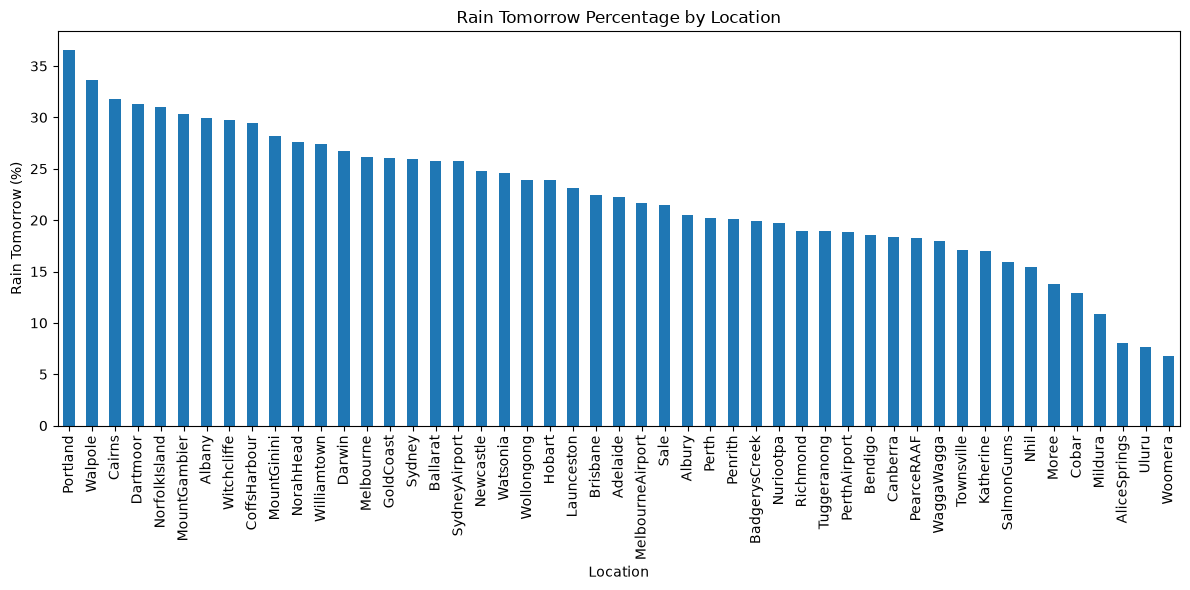

In [108]:
# Plotting how often RainTomorrow = Yes occurs at each location
plt.figure(figsize=(12, 6))

location_rain.plot(kind="bar")

plt.title("Rain Tomorrow Percentage by Location")
plt.xlabel("Location")
plt.ylabel("Rain Tomorrow (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [110]:
# Creating a temporary copy for correlation analysis
eda_corr = df_eda.copy()

# Converting the rain columns into numbers
# so they can be included in the correlation calculation
eda_corr["RainToday"] = eda_corr["RainToday"].map({
    "No": 0,
    "Yes": 1
})

eda_corr["RainTomorrow"] = eda_corr["RainTomorrow"].map({
    "No": 0,
    "Yes": 1
})

# Selecting only numerical columns
corr_cols = eda_corr.select_dtypes(
    include="number"
).columns

# Calculating the correlation between all numerical features
correlation_matrix = eda_corr[
    corr_cols
].corr()

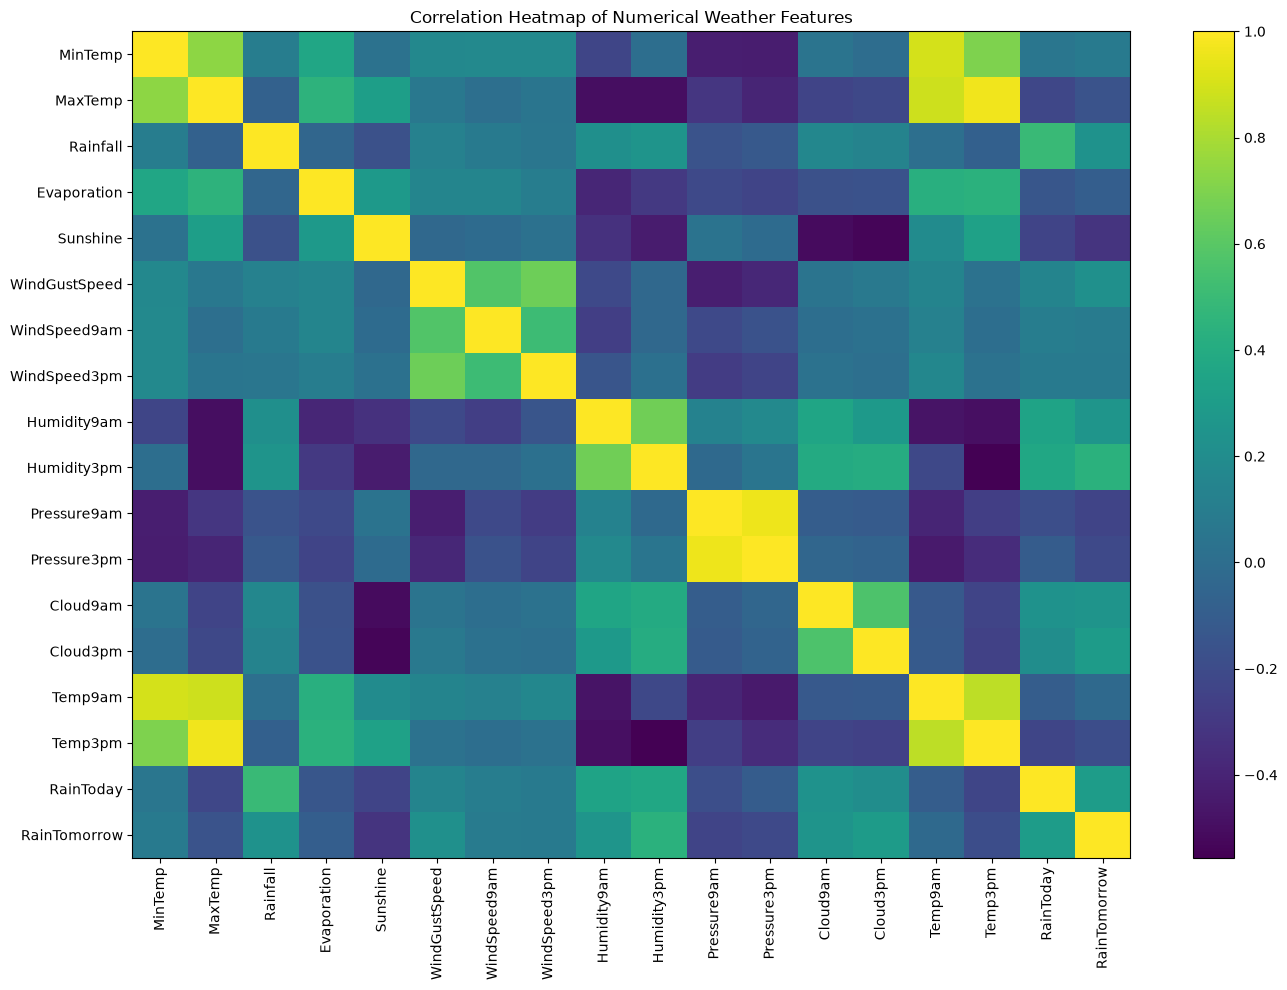

In [111]:
# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(14, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title(
    "Correlation Heatmap of Numerical Weather Features"
)

plt.tight_layout()
plt.show()

In [ ]:
# Showing which numerical features have the strongest
# relationship with the RainTomorrow target
target_correlations = (
    correlation_matrix["RainTomorrow"]
    .sort_values(ascending=False)
)

print("Correlations with RainTomorrow:")
print(target_correlations.round(3))